In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

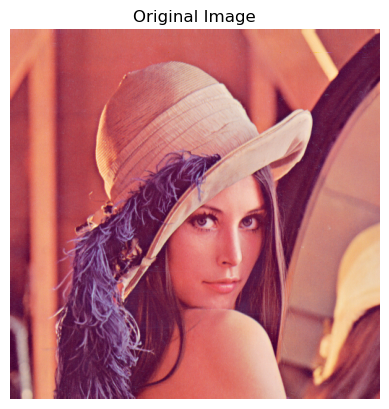

In [3]:
img = cv2.imread("Img.png")

# Convert BGR to RGB for displaying with Matplotlib
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Display original image
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

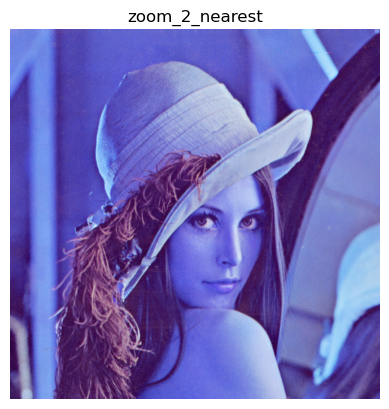

In [25]:
zoom_2_nearest = cv2.resize(
    img,
    None,
    fx=2,
    fy=2,
    interpolation=cv2.INTER_NEAREST
)
plt.imshow(zoom_2_nearest)
plt.title("zoom_2_nearest")
plt.axis("off")
plt.show()

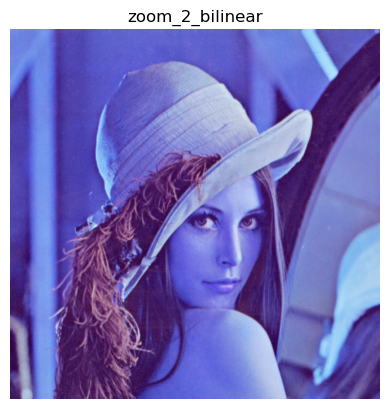

In [27]:
zoom_2_bilinear = cv2.resize(
    img,
    None,
    fx=2,
    fy=2,
    interpolation=cv2.INTER_LINEAR
)
plt.imshow(zoom_2_bilinear)
plt.title("zoom_2_bilinear")
plt.axis("off")
plt.show()

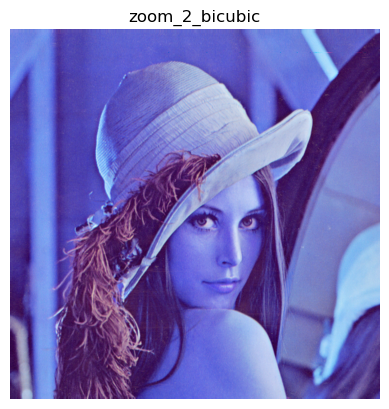

In [24]:
zoom_2_bicubic = cv2.resize(
    img,
    None,
    fx=2,
    fy=2,
    interpolation=cv2.INTER_CUBIC
)
plt.imshow(zoom_2_bicubic)
plt.title("zoom_2_bicubic")
plt.axis("off")
plt.show()

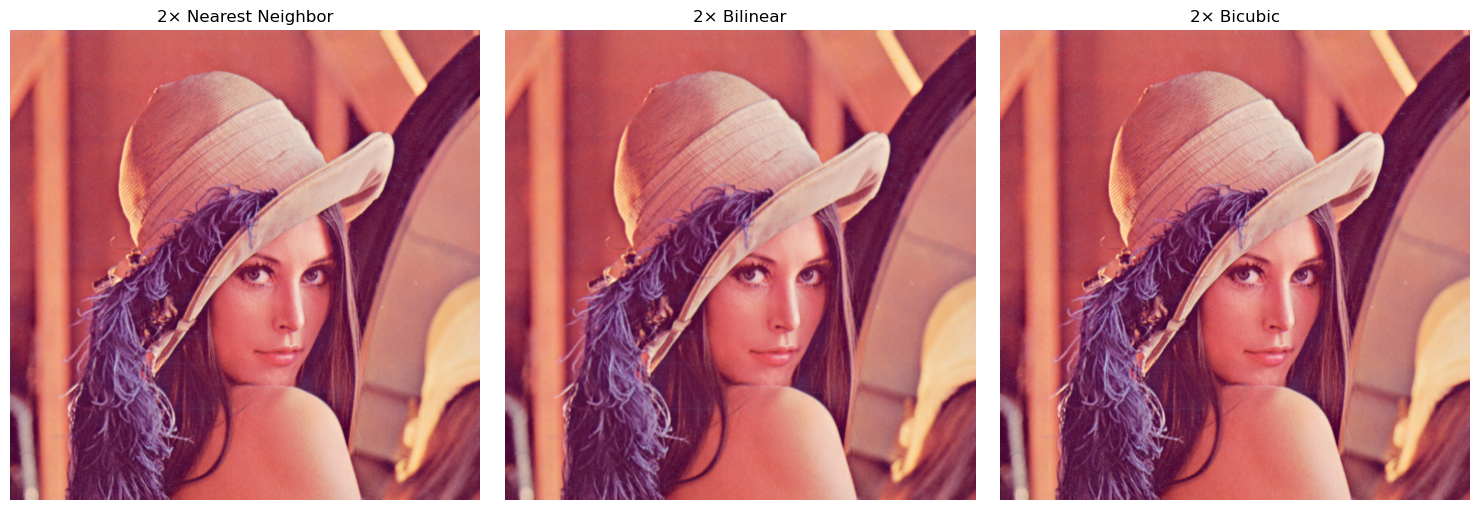

In [21]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(zoom_2_nearest, cv2.COLOR_BGR2RGB))
plt.title("2× Nearest Neighbor")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(zoom_2_bilinear, cv2.COLOR_BGR2RGB))
plt.title("2× Bilinear")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(zoom_2_bicubic, cv2.COLOR_BGR2RGB))
plt.title("2× Bicubic")
plt.axis("off")

plt.tight_layout()
plt.show()

In [22]:
zoom_4_nearest = cv2.resize(
    img, None, fx=4, fy=4,
    interpolation=cv2.INTER_NEAREST
)

zoom_4_bilinear = cv2.resize(
    img, None, fx=4, fy=4,
    interpolation=cv2.INTER_LINEAR
)

zoom_4_bicubic = cv2.resize(
    img, None, fx=4, fy=4,
    interpolation=cv2.INTER_CUBIC
)

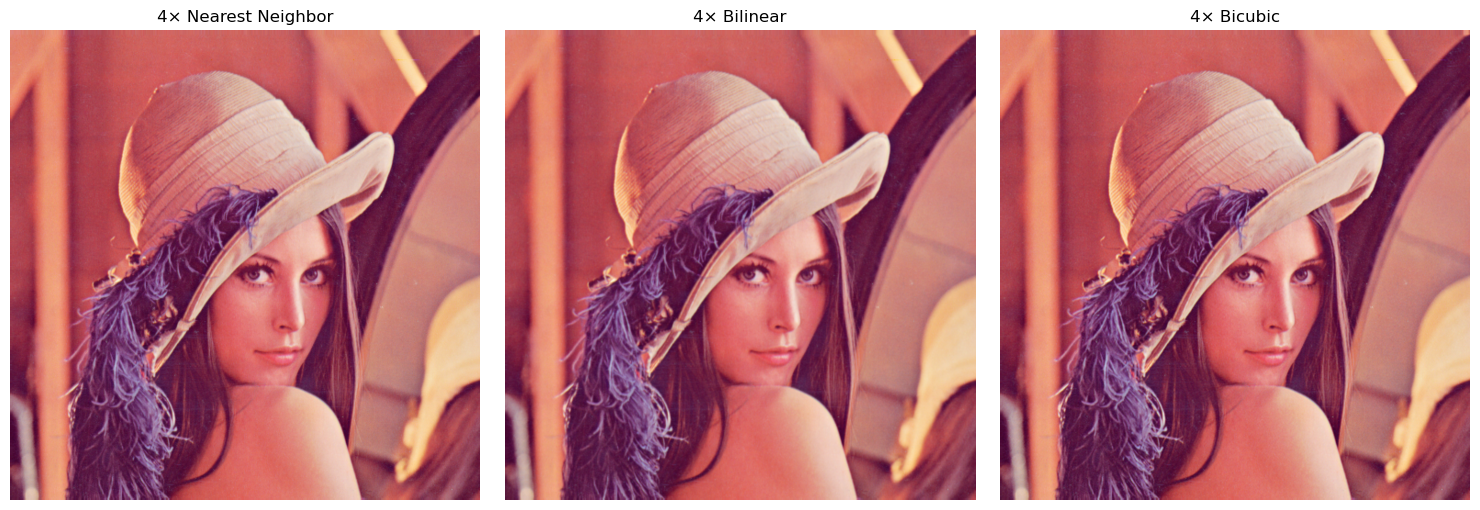

In [23]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(zoom_4_nearest, cv2.COLOR_BGR2RGB))
plt.title("4× Nearest Neighbor")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(zoom_4_bilinear, cv2.COLOR_BGR2RGB))
plt.title("4× Bilinear")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(zoom_4_bicubic, cv2.COLOR_BGR2RGB))
plt.title("4× Bicubic")
plt.axis("off")

plt.tight_layout()
plt.show()

In [28]:
shrink_half_nearest = cv2.resize(
    img, None, fx=0.5, fy=0.5,
    interpolation=cv2.INTER_NEAREST
)

shrink_half_bilinear = cv2.resize(
    img, None, fx=0.5, fy=0.5,
    interpolation=cv2.INTER_LINEAR
)

shrink_half_bicubic = cv2.resize(
    img, None, fx=0.5, fy=0.5,
    interpolation=cv2.INTER_CUBIC
)

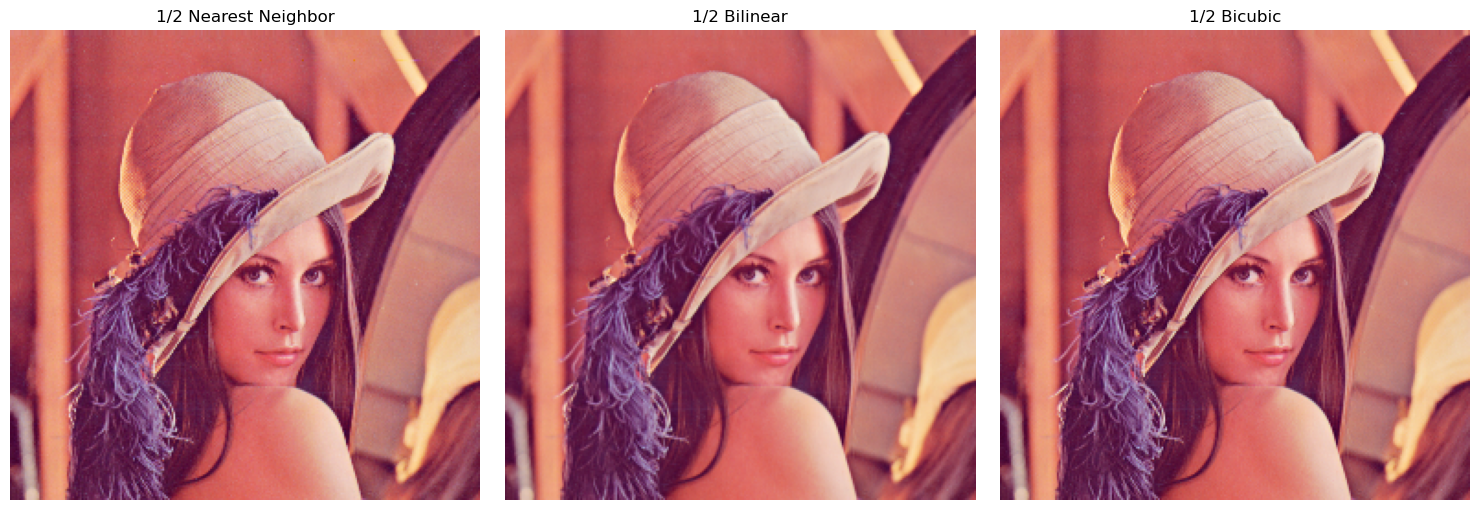

In [29]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(shrink_half_nearest, cv2.COLOR_BGR2RGB))
plt.title("1/2 Nearest Neighbor")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(shrink_half_bilinear, cv2.COLOR_BGR2RGB))
plt.title("1/2 Bilinear")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(shrink_half_bicubic, cv2.COLOR_BGR2RGB))
plt.title("1/2 Bicubic")
plt.axis("off")

plt.tight_layout()
plt.show()

In [30]:
shrink_quarter_nearest = cv2.resize(
    img, None, fx=0.25, fy=0.25,
    interpolation=cv2.INTER_NEAREST
)

shrink_quarter_bilinear = cv2.resize(
    img, None, fx=0.25, fy=0.25,
    interpolation=cv2.INTER_LINEAR
)

shrink_quarter_bicubic = cv2.resize(
    img, None, fx=0.25, fy=0.25,
    interpolation=cv2.INTER_CUBIC
)

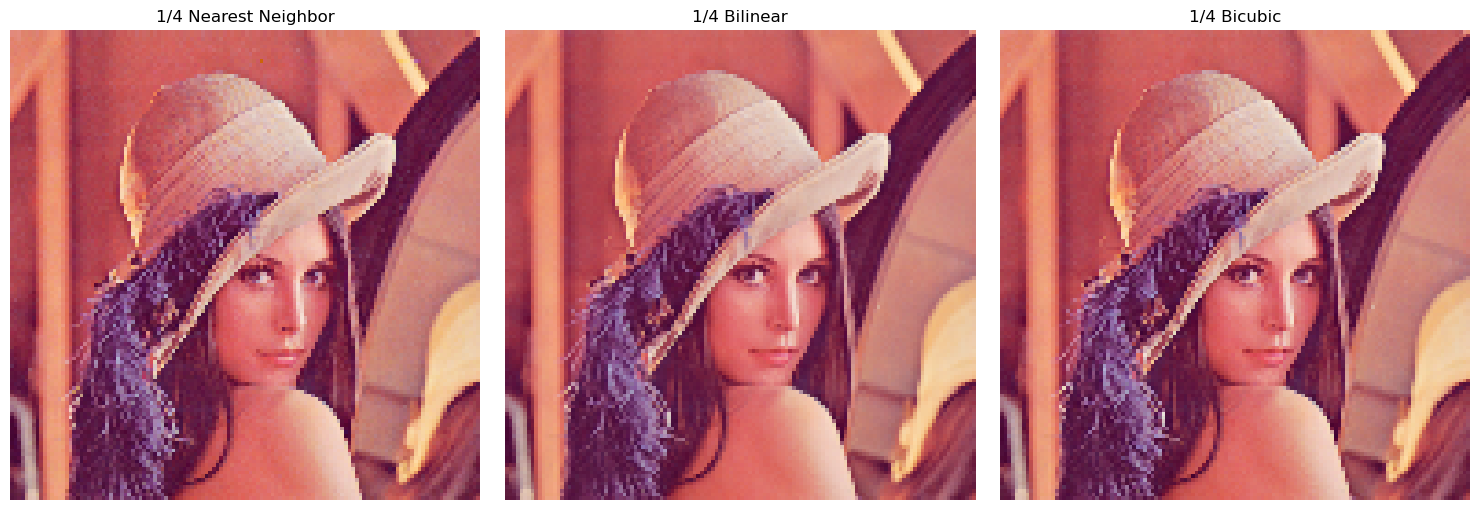

In [31]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(shrink_quarter_nearest, cv2.COLOR_BGR2RGB))
plt.title("1/4 Nearest Neighbor")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(shrink_quarter_bilinear, cv2.COLOR_BGR2RGB))
plt.title("1/4 Bilinear")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(shrink_quarter_bicubic, cv2.COLOR_BGR2RGB))
plt.title("1/4 Bicubic")
plt.axis("off")

plt.tight_layout()
plt.show()

In [32]:
def nearest_neighbor_resize(image, new_height, new_width):
    
    old_height, old_width = image.shape[:2]
    
    # Create empty output image
    output = np.zeros(
        (new_height, new_width, image.shape[2]),
        dtype=image.dtype
    )
    
    # Calculate scaling factors
    y_scale = old_height / new_height
    x_scale = old_width / new_width
    
    # Visit every pixel in output image
    for y in range(new_height):
        for x in range(new_width):
            
            # Find nearest pixel in original image
            old_y = int(y * y_scale)
            old_x = int(x * x_scale)
            
            # Copy pixel
            output[y, x] = image[old_y, old_x]
    
    return output

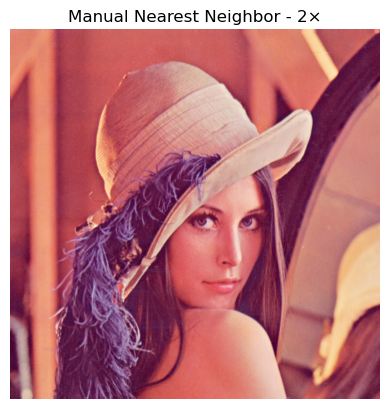

In [33]:
h, w = img.shape[:2]

manual_2x = nearest_neighbor_resize(
    img,
    h * 2,
    w * 2
)

plt.imshow(cv2.cvtColor(manual_2x, cv2.COLOR_BGR2RGB))
plt.title("Manual Nearest Neighbor - 2×")
plt.axis("off")
plt.show()

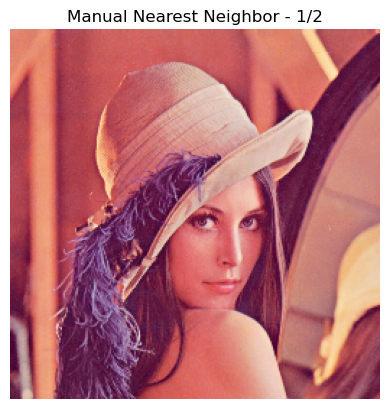

In [34]:
h, w = img.shape[:2]

manual_half = nearest_neighbor_resize(
    img,
    h // 2,
    w // 2
)

plt.imshow(cv2.cvtColor(manual_half, cv2.COLOR_BGR2RGB))
plt.title("Manual Nearest Neighbor - 1/2")
plt.axis("off")
plt.show()